In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch import linalg as LA
from einops import einsum, rearrange, reduce
import trackio as wandb


import logging

logger = logging.getLogger()

logging.basicConfig(level=logging.INFO)
logging.getLogger("httpx").disabled = True


In [57]:
class TMS(nn.Module):
    """
    TMS implementation
    x -> @ W.T -> @ W -> ReLU -> out
    """
    def __init__(self, input_dims: int = 5, hidden_dims: int = 2):
        super().__init__()
        self.input_dims = input_dims
        self.hidden_dims = hidden_dims

        self.W = nn.Parameter(torch.randn((hidden_dims, input_dims)) * 0.1)
        self.bias = nn.Parameter(torch.zeros(input_dims))
    
    def forward(self, input: torch.Tensor, W: torch.Tensor = None):
        if W is not None and torch.is_same_size(self.W, W):
            with torch.no_grad():
                hidden = input @ W.T
                out = hidden @ W
                return F.relu(out + self.bias)
            
        hidden = input @ self.W.T
        out = hidden @ self.W
        
        return F.relu(out + self.bias)
    

In [58]:
INPUT_DIMS = 5
HIDDEN_FEATS = 2

def generate_sparse_data(batch_size: int | list[int], input_dims: int, sparsity: float | list[float] = 0.1, merge: bool = True):
    """
    If batch_size is an array, sparsity should either be a float or an array of equal size. A len(batch_size) array with be returned full of tensors.
    
    If batch_size is an int, but sparsity is an array, len(sparsity) array will be returned where each element is shape [batch_size,]

    Generates batch_size x input_dims sized tensor, where each data point is an [input_dims] sized tensor.
    Where we set each feature is 1 (active) with the probability <sparsity>.
    """
    
    if isinstance(batch_size, list) and isinstance(sparsity, list):
        if len(batch_size) != len(sparsity):
            raise Exception(f"Batch size and sparsity should be equal length if passed as arrays. Found {len(batch_size)} and {len(sparsity)}")
    
    if isinstance(batch_size, list) and isinstance(sparsity, float):
        sparsity = [sparsity] * len(batch_size)
    
    if isinstance(batch_size, int) and isinstance(sparsity, list):
        batch_size = [batch_size] * len(sparsity)
    
    if isinstance(batch_size, int) and isinstance(sparsity, float):
        batch_size = [batch_size]
        sparsity = [sparsity]

    _all = []
    
    for i, s in enumerate(sparsity):
        if s > 1:
            logger.warning(f"Sparsity at index {i} was >= 1 ({s}), setting those to 1.")
            sparsity[i] = 1.0


    for bs, sp in zip(batch_size, sparsity):
        shape = (bs, input_dims)

        data = torch.rand(shape)
        mask = torch.rand(shape) > sp

        data.masked_fill_(mask, 0.0)
        _all.append(data)

    if len(_all) == 1:
        return _all[0]
    
    if merge:
        return torch.concat(_all)

    return _all


def train_tms(model: TMS, steps: int=5000, batch_size: int=256, lr=2e-4, sparsity: float | list[float]=0.2):
    """Trainszzzz"""
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr)

    pbar = tqdm(range(steps))
    losses = []

    merge_data = False

    if isinstance(sparsity, list):
        merge_data = True

    print("Training TMS model with:")
    print("in_features:", model.input_dims)
    print("hidden_dims:", model.hidden_dims)
    print("training data with sparsities:", sparsity)

    for step in pbar:
        data = generate_sparse_data(
            batch_size=batch_size, input_dims=model.input_dims, sparsity=sparsity, merge=merge_data
        )

        # for batch in loader
        optimiser.zero_grad()

        loss = (model(data) - data).pow(2).mean()
        losses.append(loss.item())
        pbar.set_description(f"Step: {step} / {steps}::loss: {loss.item():.4f}")

        loss.backward()

        optimiser.step()

    return losses


model = TMS(input_dims=INPUT_DIMS, hidden_dims=HIDDEN_FEATS)

losses = train_tms(model, steps=10000, sparsity=[0.1, 0.2, 0.4])

Step: 339 / 10000::loss: 0.0640:   2%|▏         | 173/10000 [00:00<00:05, 1721.76it/s]

Training TMS model with:
in_features: 5
hidden_dims: 2
training data with sparsities: [0.1, 0.2, 0.4]


Step: 9999 / 10000::loss: 0.0239: 100%|██████████| 10000/10000 [00:06<00:00, 1583.24it/s]


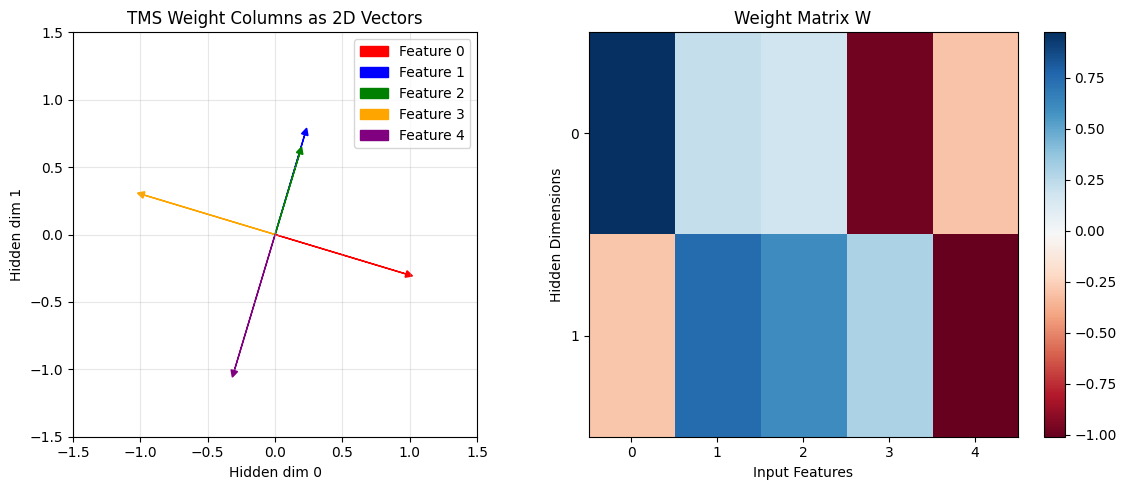

Weight matrix W:
[[ 0.97131956  0.2198902   0.18205452 -0.97332954 -0.3026456 ]
 [-0.29274797  0.74083835  0.60119927  0.2934022  -1.0095463 ]]

Column norms:
Feature 0: 1.014
Feature 1: 0.773
Feature 2: 0.628
Feature 3: 1.017
Feature 4: 1.054


In [59]:
# First, let's look at your trained weights
def visualize_tms_weights(model: TMS):
    W = model.W.detach().cpu().numpy()  # Shape: [HIDDEN_FEATS, input_dims]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Weight matrix as 2D vectors
    ax1.set_xlim(-1.5, 1.5)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_aspect('equal')
    
    ax1.grid(True, alpha=0.3)
    ax1.set_title('TMS Weight Columns as 2D Vectors')
    ax1.set_xlabel('Hidden dim 0')
    ax1.set_ylabel('Hidden dim 1')
    
    # Plot each column as a vector from origin
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i in range(model.input_dims):
        ax1.arrow(0, 0, W[0, i], W[1, i], 
                 head_width=0.05, head_length=0.05, 
                 fc=colors[i], ec=colors[i], 
                 label=f'Feature {i}')
    ax1.legend()
    
    # Plot 2: Weight matrix heatmap
    im = ax2.imshow(W, cmap='RdBu', aspect='auto')
    ax2.set_title('Weight Matrix W')
    ax2.set_xlabel('Input Features')
    ax2.set_ylabel('Hidden Dimensions')
    ax2.set_xticks(range(model.input_dims))
    ax2.set_yticks(range(HIDDEN_FEATS))
    plt.colorbar(im, ax=ax2)
    
    plt.tight_layout()
    return fig

# Visualize your trained model
fig = visualize_tms_weights(model)
plt.show()

# Print weight values
print("Weight matrix W:")
print(model.W.detach().numpy())
print("\nColumn norms:")
for i in range(model.input_dims):
    norm = torch.norm(model.W[:, i]).item()
    print(f"Feature {i}: {norm:.3f}")

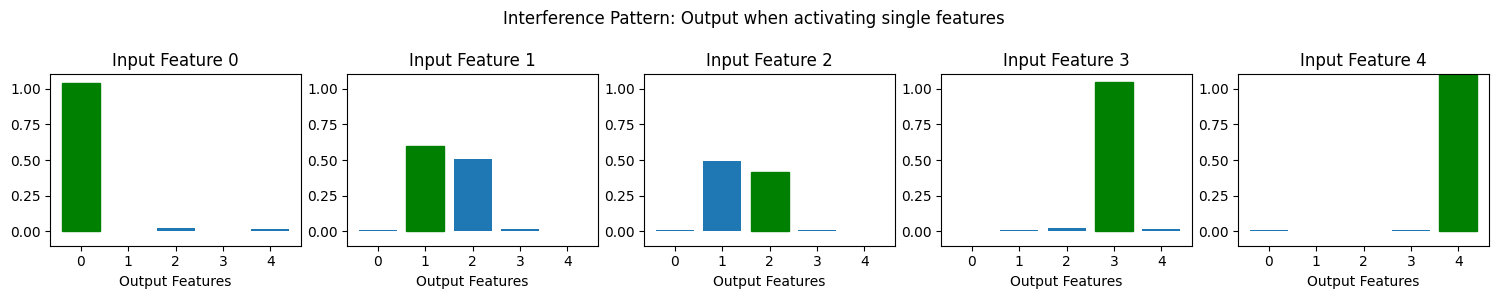

In [60]:
def visualize_interference(model: TMS):
    """Visualize how activating one feature affects others"""
    fig, axes = plt.subplots(1, model.input_dims, figsize=(15, 3))
    
    for feature_idx in range(model.input_dims):
        x = torch.zeros(1, model.input_dims)
        x[0, feature_idx] = 1.0
        
        with torch.no_grad():
            output = model(x).squeeze()
        
        ax = axes[feature_idx]
        ax.bar(range(model.input_dims), output.numpy())
        ax.set_ylim(-0.1, 1.1)
        ax.set_title(f'Input Feature {feature_idx}')
        ax.set_xlabel('Output Features')
        ax.set_xticks(range(model.input_dims))
        
        # Highlight the target feature
        ax.get_children()[feature_idx].set_color('green')
    
    plt.suptitle('Interference Pattern: Output when activating single features')
    plt.tight_layout()
    return fig

fig = visualize_interference(model)
plt.show()

In [64]:
class APDTrainer(nn.Module):
    def __init__(
        self,
        n_components: int,
        input_dims: int,
        hidden_dims: int,
        train_sparsities: list[float] = None,
        debug: bool = False,
    ):
        super().__init__()
        self.tms_model = TMS(input_dims=input_dims, hidden_dims=hidden_dims)

        self.input_dims = input_dims
        self.hidden_dims = hidden_dims

        if train_sparsities is None:
            self.train_sparsities = np.arange(0, 0.5, 0.2).tolist()
        else:
            self.train_sparsities = train_sparsities

        self.W_flat = self.tms_model.W.flatten()

        if debug:
            print(self.W_flat.shape)

        self.debug = debug

        self.n_components = n_components

        self.components = nn.Parameter(
            0.1 * torch.randn((n_components, self.W_flat.shape[0]))
        )

        self.optimizer = torch.optim.AdamW(params=[self.components], lr=1e-3)

        self.losses = []

        self.step = 0

    def metrics(self, debug = False):
        components_reshaped = self.components.reshape((self.n_components, *self.tms_model.W.shape))
        components_norm = components_reshaped.norm(p=2, dim=1, keepdim=True)
        if debug:
            print("components_reshaped.shape", components_reshaped.shape)
            print("components_norm.shape", components_norm.shape)

        components_normed =  components_reshaped / components_norm
        if debug:
            print("components_normed.shape after normalisation", components_normed.shape)
        weights = self.tms_model.W.detach()
        weights_norm = weights.norm(p=2, dim=0, keepdim=True)
        if debug:
            print("weights column norm", weights_norm)
            print("weights.shape", weights.shape)
            print("weights_norm.shape", weights.shape)


        weights_normed = weights / weights_norm

        # n_components x input_features
        dot: torch.Tensor = einsum(components_normed, weights_normed, "nc hidden input, hidden input -> nc input")
        
        # n_components x 1
        mcs, mcs_idx = dot.max(dim=0)

        mmcs = mcs.mean().item()

        # for ml2r
        # we use the above mcs_idx, which has the index of the parameter which had the highest dot product with a specific column of the weight matrix
        # self.n_inputs x self.n_features (note that this is transpose of weights. but no matter)
        # also note we use NON normalised pc here because we need to compare the norm
        max_pcj: torch.Tensor = components_reshaped[mcs_idx, :, range(self.input_dims)]


        max_pcj_normed = max_pcj.norm(p=2, dim=1)

        l2r = (max_pcj_normed / weights.norm(p=2, dim=0))
        ml2r = l2r.mean().item()

        if debug:
            print("mcs", mcs)
            print("mcs_idx", mcs_idx)
            print("max_pcj", max_pcj)
            print("max_pcj_normed", max_pcj_normed)
            print("l2r", l2r)


        return {
            "mmcs": mmcs,
            "ml2r": ml2r
        }


    def train(
        self,
        epochs: int = 5000,
        batch_size: int = 256,
        lambda_minimal: float = 7.0,
        lambda_faithful: float = 20.0,
        lambda_simple: float = 0.01,
    ):
        self.step = 0

        if self.debug:
            print("="*10)
            print("DEBUG MODE. ONLY ONE ITERATION OF APD WILL BE RUN. DEBUG=FALSE TO ACTUALLY TRAIN.")
           
            print("DEBUG MODE. ONLY ONE ITERATION OF APD WILL BE RUN. DEBUG=FALSE TO ACTUALLY TRAIN.")
            print("="*10)

        if not self.debug:
            wandb.init(project="apd-training", name=f"apd_in_{self.input_dims}_hidn_{self.hidden_dims}", config={
                "epochs": epochs,
                "batch_size": batch_size,
                "lambda_minimal": lambda_minimal,
                "lambda_faithful": lambda_faithful,
                "lambda_simple": lambda_simple,
                "hidden_dims": self.hidden_dims,
                "input_dims": self.input_dims
            })


        # train the tms model
        train_tms(self.tms_model, sparsity=[0.1, 0.2, 0.4])

        self.W_flat = self.tms_model.W.flatten()

        if self.debug:
            print(self.W_flat.shape)

        train_data = generate_sparse_data(
            batch_size, self.tms_model.input_dims, self.train_sparsities
        )

        loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)


        print("=" * 10)
        print("Training APD")
        print("n_components:", self.n_components)
        print("Total epochs:", epochs)
        print("Total batches:", len(loader))
        print("Train samples per batch:", len(train_data))
        print("Sparsities trained for:", self.train_sparsities)

        for i, epoch in tqdm(enumerate(range(epochs))):
            for j, batch in enumerate(loader):
                self.step += 1
                self.optimizer.zero_grad()

                output: torch.Tensor = self.tms_model(batch)

                loss = output.pow(2).sum(dim=-1).mean()

                if self.debug:
                    print("loss.shape", loss.shape)

                loss.backward()

                gradients = self.tms_model.W.grad.flatten()
                if self.debug:
                    print("gradients.shape", gradients.shape)
                    print("components.shape", self.components.shape)

                attributions = einsum(gradients, self.components, "w, c_i w -> c_i")

                if self.debug:
                    print("attributions.shape before sum", attributions.shape)
                if self.debug:
                    print("attributions.shape after sum", attributions.shape)

                output_original = output.detach()

                self.tms_model.W.grad = None

                top_k_components = self.components[
                    attributions.topk(
                        k=5 if 5 < self.n_components else self.n_components, dim=0
                    ).indices,
                ]
                W_sparse = top_k_components.sum(dim=0)  # 1 x W_flat.shape
                W_sparse = W_sparse.reshape(self.tms_model.W.shape)

                output_sparse = self.tms_model.forward(batch, W_sparse).detach()

                if self.debug:
                    print("output_original.shape", output_original.shape)
                    print("output_sparse.shape", output_sparse.shape)

                loss_minimal = (output_sparse - output_original).pow(2).mean()
                loss_faithful = (self.components.sum(dim=0) - self.W_flat).pow(2).mean()

                # the math for this went over my head quite quickly.
                # just vomiting for now
                loss_simple = (
                    self.components.reshape((self.n_components, *self.tms_model.W.shape))
                    .norm(p=0.5, dim=(1, 2))
                    .sum()
                )

                total_loss = (
                    lambda_minimal * loss_minimal
                    + lambda_faithful * loss_faithful
                    + lambda_simple * loss_simple
                )

                losses = {
                    "loss_minimal": loss_minimal.item(),
                    "loss_faithful": loss_faithful.item(),
                    "loss_simple": loss_simple.item(),
                    "total_loss": total_loss.item()
                }

                self.losses.append(losses)

                metrics = {}
                if self.step % 100 == 0:
                    metrics = self.metrics()
                    wandb.log({
                        "epoch": epoch,
                        **losses,
                        **metrics
                    }, self.step)

                total_loss.backward()

                self.optimizer.step()

                if self.debug:
                    print("="*10)
                    print("DEBUG MODE. ONLY ONE ITERATION OF APD WILL BE RUN. DEBUG=FALSE TO ACTUALLY TRAIN.")
                    break
            if self.debug:
                print("DEBUG MODE. ONLY ONE ITERATION OF APD WILL BE RUN. DEBUG=FALSE TO ACTUALLY TRAIN.")
                print("="*10)
                break

    def visualize_apd_vectors(self):
        W = self.tms_model.W.detach().cpu().numpy()
        num_components = self.n_components
        
        fig, axes = plt.subplots(1, num_components + 2, figsize=(4*(num_components+2), 4))

        # Generate a distinct color for each input feature using a colormap
        colors = plt.cm.tab20(np.linspace(0, 1, W.shape[1]))

        # Original W
        axes[0].set_title("Target model (W)")
        for i, col in enumerate(range(W.shape[1])):
            axes[0].arrow(0, 0, W[0, col], W[1, col], head_width=0.05, head_length=0.05,
                        fc=colors[i], ec=colors[i])
        axes[0].axhline(0, color='gray', lw=0.5)
        axes[0].axvline(0, color='gray', lw=0.5)
        axes[0].set_xlim(-1.5, 1.5)
        axes[0].set_ylim(-1.5, 1.5)
        axes[0].set_aspect('equal')

        # Sum of components
        sum_comp = self.components.sum(dim=0).detach().cpu().reshape(W.shape)
        axes[1].set_title("Sum of components")
        for i, col in enumerate(range(sum_comp.shape[1])):
            axes[1].arrow(0, 0, sum_comp[0, col], sum_comp[1, col], head_width=0.05, head_length=0.05,
                        fc=colors[i], ec=colors[i])
        axes[1].axhline(0, color='gray', lw=0.5)
        axes[1].axvline(0, color='gray', lw=0.5)
        axes[1].set_xlim(-1.5, 1.5)
        axes[1].set_ylim(-1.5, 1.5)
        axes[1].set_aspect('equal')

        # Individual components
        for idx in range(num_components):
            comp = self.components[idx].detach().cpu().reshape(W.shape)
            axes[idx+2].set_title(f"Component {idx}")
            for i, col in enumerate(range(comp.shape[1])):
                axes[idx+2].arrow(0, 0, comp[0, col], comp[1, col], head_width=0.05, head_length=0.05,
                                fc=colors[i], ec=colors[i])
            axes[idx+2].axhline(0, color='gray', lw=0.5)
            axes[idx+2].axvline(0, color='gray', lw=0.5)
            axes[idx+2].set_xlim(-1.5, 1.5)
            axes[idx+2].set_ylim(-1.5, 1.5)
            axes[idx+2].set_aspect('equal')

        plt.tight_layout()
        plt.show()


# Recreating this graphic

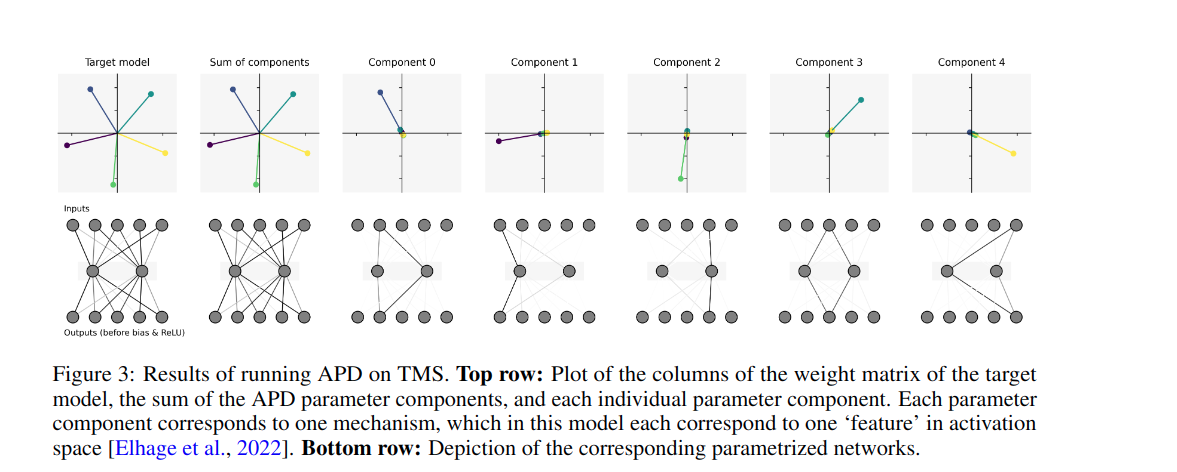

In [65]:
INPUT_DIMS = 5
HIDDEN_FEATS = 2

N_COMPONENTS = INPUT_DIMS + 1
BS = 256

EPOCHS = 2000

DEBUG = False

s = np.arange(0, 0.5, 0.2).tolist()
apd = APDTrainer(n_components=N_COMPONENTS, hidden_dims=HIDDEN_FEATS, input_dims=INPUT_DIMS, train_sparsities=s)

Step: 287 / 5000::loss: 0.0619:   3%|▎         | 133/5000 [00:00<00:03, 1323.71it/s]

Training TMS model with:
in_features: 5
hidden_dims: 2
training data with sparsities: [0.1, 0.2, 0.4]


Step: 4999 / 5000::loss: 0.0269: 100%|██████████| 5000/5000 [00:03<00:00, 1558.80it/s]


Training APD
n_components: 6
Total epochs: 5000
Total batches: 3
Train samples per batch: 768
Sparsities trained for: [0.0, 0.2, 0.4]


5000it [00:29, 171.78it/s]


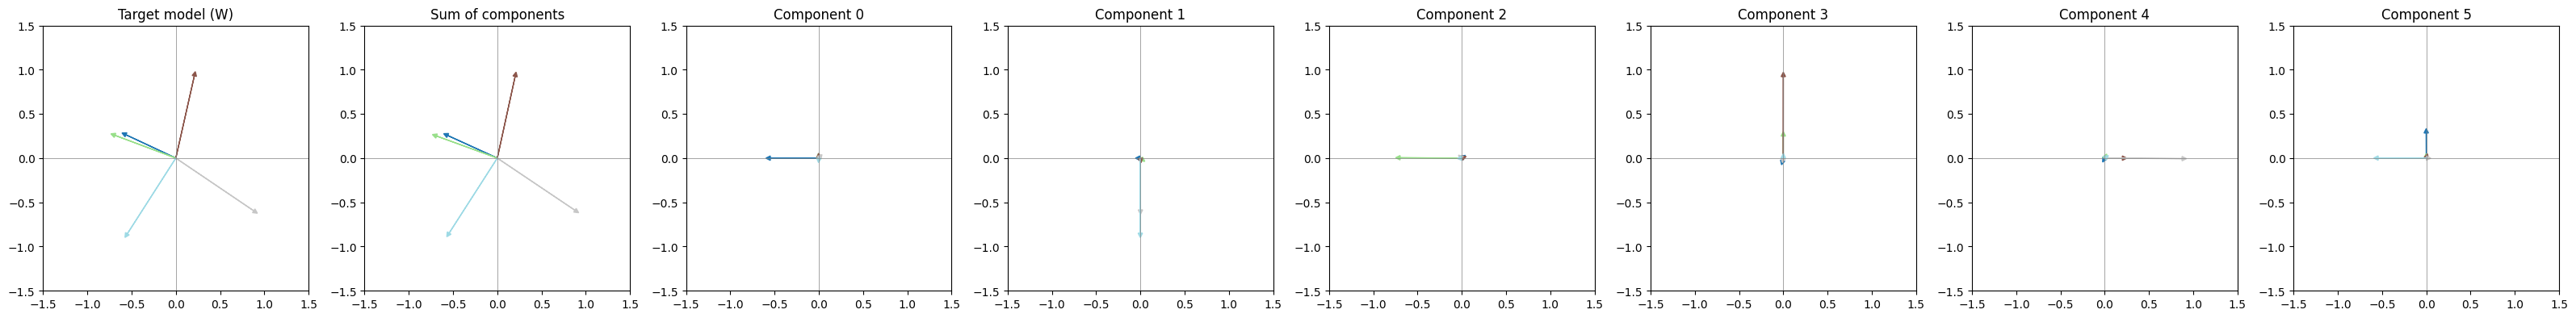

In [66]:
apd.train()

apd.visualize_apd_vectors()

In [31]:
apd.metrics(debug=True)

components_reshaped.shape torch.Size([6, 2, 5])
components_norm.shape torch.Size([6, 1, 5])
components_normed.shape after normalisation torch.Size([6, 2, 5])
weights column norm tensor([[1.0140, 1.0161, 1.0148, 1.0162, 0.0136]])
weights.shape torch.Size([2, 5])
weights_norm.shape torch.Size([2, 5])
mcs tensor([0.8840, 1.0000, 0.8383, 0.9973, 0.7272], grad_fn=<MaxBackward0>)
mcs_idx tensor([5, 3, 3, 4, 1])
max_pcj tensor([[-3.5600e-04,  1.4323e-03],
        [ 6.6436e-01, -7.5392e-01],
        [-4.8706e-03, -7.6095e-04],
        [ 8.7961e-04,  6.8013e-04],
        [-1.0173e-03, -5.1158e-05]], grad_fn=<IndexBackward0>)
max_pcj_normed tensor([0.0015, 1.0049, 0.0049, 0.0011, 0.0010],
       grad_fn=<LinalgVectorNormBackward0>)
l2r tensor([0.0015, 0.9889, 0.0049, 0.0011, 0.0747], grad_fn=<DivBackward0>)


{'mmcs': 0.8893505334854126, 'ml2r': tensor(0.2142, grad_fn=<MeanBackward0>)}

# Learnings:


If you set:
```
N_COMPONENTS = 2
input_dims = 5
```

You will pretty quickly learn the below insight from the paper. I found that I could get maybe 1 in 40 runs looking right. So strange. Tried changing loads of stuff too!

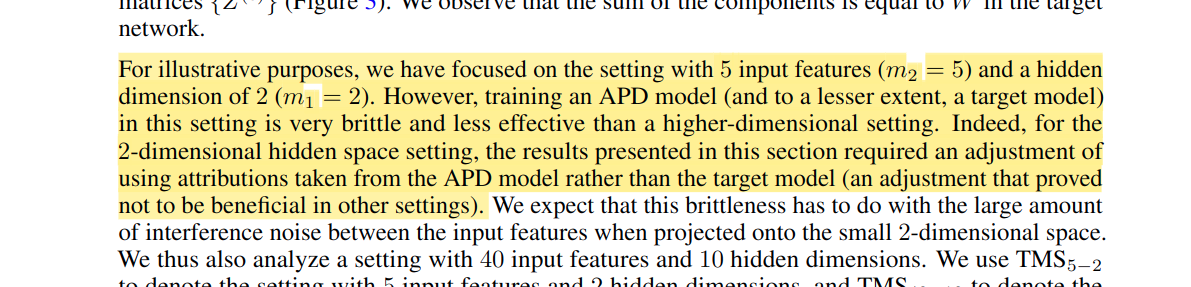


Let us try with more components and features

In [ ]:
INPUT_DIMS = 40
N_COMPONENTS = INPUT_DIMS + 3
BS = 256

EPOCHS = 2000

DEBUG = False

HIDDEN_FEATS = 10


s = np.arange(0, 0.5, 0.2).tolist()

apd_40_10 = APDTrainer(n_components=N_COMPONENTS, hidden_dims=HIDDEN_FEATS, input_dims=INPUT_DIMS, train_sparsities=s)

apd_40_10.train()


Step: 194 / 5000::loss: 0.0516:   2%|▏         | 98/5000 [00:00<00:05, 976.14it/s]

Training TMS model with:
in_features: 40
hidden_dims: 10
training data with sparsities: [0.1, 0.2, 0.4]


Step: 4999 / 5000::loss: 0.0366: 100%|██████████| 5000/5000 [00:04<00:00, 1027.87it/s]


Training APD
n_components: 43
Total epochs: 5000
Total batches: 3
Train samples per batch: 768
Sparsities trained for: [0.0, 0.2, 0.4]


5000it [00:12, 414.39it/s]


In [38]:
apd_40_10.metrics()

{'mmcs': 0.63372802734375, 'ml2r': tensor(0.0363, grad_fn=<MeanBackward0>)}

In [37]:
apd_40_10.tms_model.W.shape, apd.tms_model.W.shape

(torch.Size([10, 40]), torch.Size([2, 5]))